# Проектная работа по анализу крупного интернет-магазина

Цель: определить наиболее перспективные гипотезы и проанализировать результаты A/B-теста для увеличения выручки крупного интернет-магазина

***План работ:***

**Часть 1. Приоритизация гипотез**\
В файле /datasets/hypothesis.csv 9(девять) гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.\
Задача
- Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
- Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
- Укажите, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясните, почему так произошло.

**Часть 2. Анализ A/B-теста**\
Вы провели A/B-тест и получили результаты, которые описаны в файлах /datasets/orders.csv и /datasets/visitors.csv.\
Задача\
Проанализируйте A/B-тест:\
    2.1 Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения\
2.2 Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения\
2.3 Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения\
2.4 Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения\
2.5 Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения\
2.6 Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения\
2.7 Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей\
2.8 Постройте точечный график стоимостей заказов. Сделайте выводы и предположения\
2.9 Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов\
2.10 Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения\
2.11 Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения\
2.12 Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения\
2.13 Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения\
2.14 Примите решение по результатам теста и объясните его. Варианты решений:\
        1. Остановить тест, зафиксировать победу одной из групп\
        2. Остановить тест, зафиксировать отсутствие различий между группами\
        3. Продолжить тест

## Часть 1. Приоритизация гипотез

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import scipy.stats as stats
from scipy import stats as st
import math
import numpy as np
import datetime as dt
import seaborn as sns

In [2]:
data = pd.read_csv('/datasets/hypothesis.csv')
pd.options.display.max_colwidth = 130
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1


In [3]:
# преобразование имен всех столбцов к нижнему регистру
data.rename(columns=str.lower, inplace=True)

In [4]:
display(data.isna().sum()) # количество пропущенных значений для каждого столбца 
data.duplicated().sum() # число дубликатов 

hypothesis    0
reach         0
impact        0
confidence    0
efforts       0
dtype: int64

0

reach — скольких пользователей затронет изменение, которое вы хотите внести;\
impact — насколько сильно изменение повлияет на пользователей, их опыт и удовлетворение от продукта;\
confidence — насколько вы уверены, что это изменение повлияет на пользователей именно так; \
efforts — сколько стоит протестировать эту гипотезу;\
hypothesis — гипотеза

### Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета

In [5]:
data['iсe']=(data['impact']*data['confidence'])/data['efforts']
pd.set_option('display.max_columns', None) # расширить отображение вывода
pd.options.display.float_format = '{:,.2f}'.format # округление до 2 знаков после запятой вычисления 
display(data.sort_values(by='iсe', ascending=False))

,hypothesis,reach,impact,confidence,efforts,iсe
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


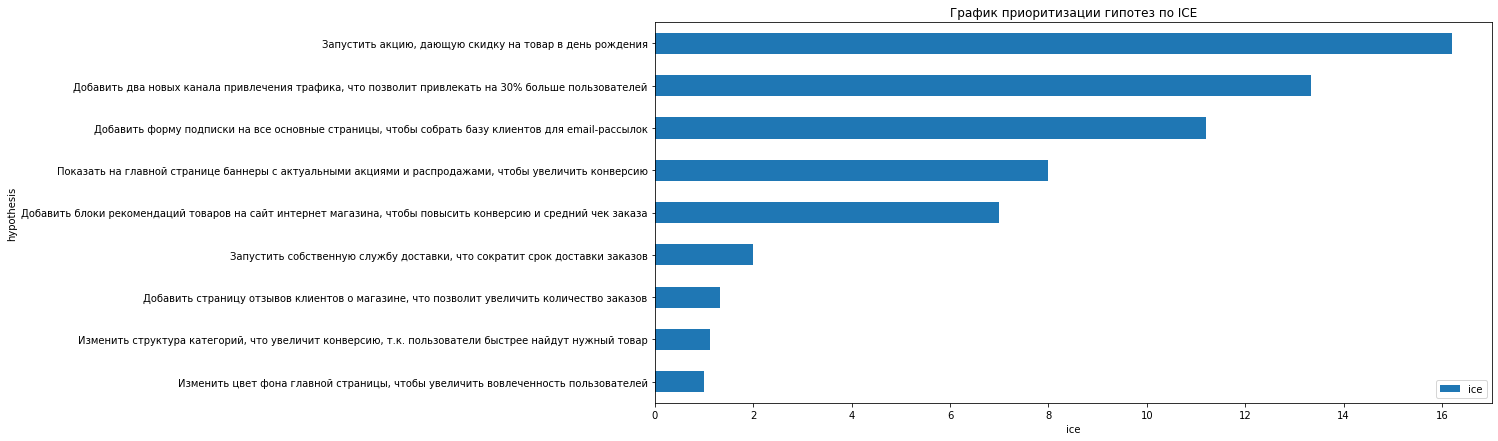

In [6]:
data.sort_values(by='iсe').plot(kind = 'barh', x='hypothesis', y='iсe', figsize = (15,7))
plt.title('График приоритизации гипотез по ICE')
plt.xlabel('iсe')
plt.legend()
plt.show();

***Итог:***
Наиболее перспективные гипотезы по ICE: 8, 0, 7, 6, 2.

### Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета

In [7]:
data['riсe']=(data['reach']*data['impact']*data['confidence'])/data['efforts']
display(data.sort_values(by='riсe', ascending=False))

,hypothesis,reach,impact,confidence,efforts,iсe,riсe
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.00
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.00
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.20
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.00
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.00


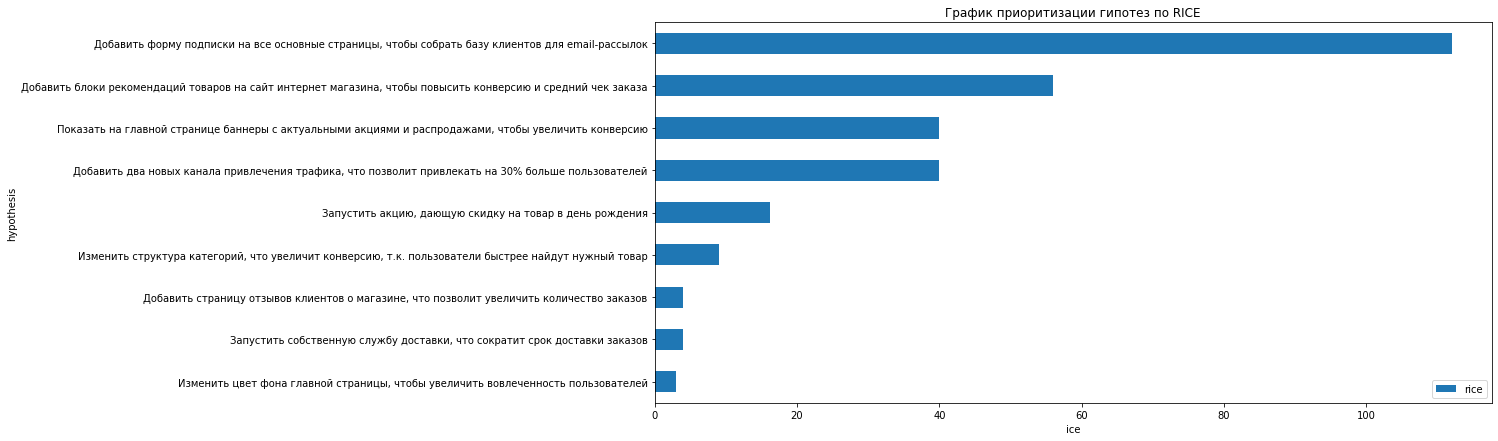

In [8]:
data.sort_values(by='riсe').plot(kind = 'barh', x='hypothesis', y='riсe', figsize = (15,7))
plt.title('График приоритизации гипотез по RICE')
plt.xlabel('iсe')
plt.legend()
plt.show();

***Итог:***
Наиболее перспективные гипотезы по RICE:  7, 2, 0, 6, 8. 

### Укажите, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясните, почему так произошло

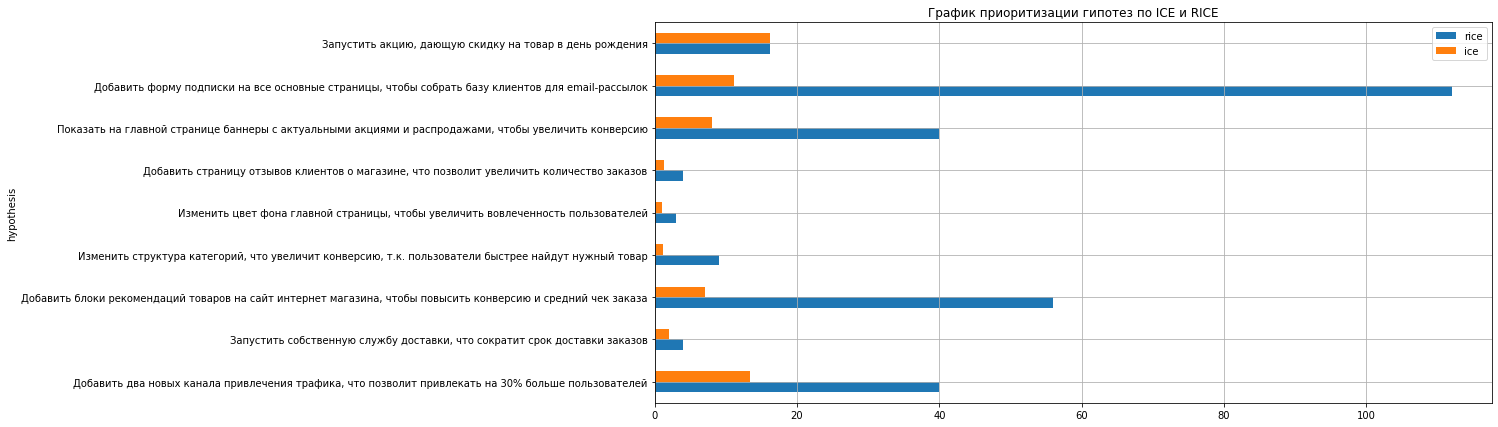

In [9]:
data.plot(kind = 'barh', x='hypothesis', y=['riсe','iсe'], figsize = (15,7), grid=True,)
plt.title('График приоритизации гипотез по ICE и RICE')
plt.legend()
plt.show()

***Итог:***
Наиболее перспективные гипотезы по ICE и RICE одни и те же, но порядок приоритизации по RICE изменился, так как оказывает влияние параметр reach, показывающий скольких пользователей затронет изменение.

***Вывод:***
Файл содержит 9 гипотез и оценки по 4 параметрам - reach, impact, confidence, efforts.
По разным методам приоритизации гипотез ICE и RICE наиболее перспективными гипотезами оказались одинаковы - 8, 0, 7, 6, 2. Однако по RICE немного другой порядок приоритизации гипотез из-за влияния параметра reach - 7, 2, 0, 6, 8, который учитывает число пользователей, претерпевающих данные изменения. Точная оценка гипотез зависит от метода, поэтому смотрим на место гипотез относительно друг другу, а не на абсолютную оценку. 

Приоритизации гипотез по RICE:
- добавить форму подписи на все основные страницы, чтобы собрать базу клиентов для рассылок;
- добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа;
- показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию;
- добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей;
- запустить акцию, дающую скидку на товар в день рождения.

## Часть 2. Анализ A/B-теста

In [10]:
orders = pd.read_csv('/datasets/orders.csv', parse_dates=['date'])
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


Изменили тип данных столбца 'date'.

In [11]:
orders['date'].sort_values().unique()

array(['2019-08-01T00:00:00.000000000', '2019-08-02T00:00:00.000000000',
       '2019-08-03T00:00:00.000000000', '2019-08-04T00:00:00.000000000',
       '2019-08-05T00:00:00.000000000', '2019-08-06T00:00:00.000000000',
       '2019-08-07T00:00:00.000000000', '2019-08-08T00:00:00.000000000',
       '2019-08-09T00:00:00.000000000', '2019-08-10T00:00:00.000000000',
       '2019-08-11T00:00:00.000000000', '2019-08-12T00:00:00.000000000',
       '2019-08-13T00:00:00.000000000', '2019-08-14T00:00:00.000000000',
       '2019-08-15T00:00:00.000000000', '2019-08-16T00:00:00.000000000',
       '2019-08-17T00:00:00.000000000', '2019-08-18T00:00:00.000000000',
       '2019-08-19T00:00:00.000000000', '2019-08-20T00:00:00.000000000',
       '2019-08-21T00:00:00.000000000', '2019-08-22T00:00:00.000000000',
       '2019-08-23T00:00:00.000000000', '2019-08-24T00:00:00.000000000',
       '2019-08-25T00:00:00.000000000', '2019-08-26T00:00:00.000000000',
       '2019-08-27T00:00:00.000000000', '2019-08-28

Данные за август 2019 года.

In [12]:
orders.columns=orders.columns.str.replace('Id', '_id')

In [13]:
display(orders.isna().sum()) # количество пропущенных значений для каждого столбца 
orders.duplicated().sum() # число дубликатов 

transaction_id    0
visitor_id        0
date              0
revenue           0
group             0
dtype: int64

0

In [14]:
orders['revenue'].describe()

count       1,197.00
mean        8,348.01
std        39,191.13
min            50.00
25%         1,220.00
50%         2,978.00
75%         8,290.00
max     1,294,500.00
Name: revenue, dtype: float64

Выручка заказа колеблется от 50 руб. до 1.3 млн. Медиана сильно отличается от среднего значения выручки. Следовательно, есть выбросы. 

In [15]:
orders['revenue'].sort_values(ascending=False).head(10)

425     1294500
1196     202740
858       93940
1136      92550
744       86620
682       78990
662       78990
743       67990
1103      66350
1099      65710
Name: revenue, dtype: int64

Видим 2 крупных заказа №425 и 1196 - выбросы.

In [16]:
# число заказов по дате и группам
orders.groupby(['date','group'])['transaction_id'].count().sort_values(ascending=False).head(20)

date        group
2019-08-15  B        31
2019-08-28  B        28
2019-08-27  A        28
2019-08-06  B        28
2019-08-08  B        27
2019-08-23  A        25
2019-08-09  B        25
2019-08-22  B        25
2019-08-05  A        25
2019-08-26  B        25
2019-08-07  B        24
2019-08-14  A        24
2019-08-12  A        24
2019-08-01  A        24
2019-08-03  A        24
2019-08-02  B        24
2019-08-30  B        24
2019-08-05  B        23
2019-08-21  A        23
2019-08-10  B        23
Name: transaction_id, dtype: int64

Кол-во заказов на группу В приходится больше.

In [17]:
orders.groupby('group')['visitor_id'].count()

group
A    557
B    640
Name: visitor_id, dtype: int64

Количество пользователей в группе А - 557, в группе В - 640.

In [18]:
# какие пользователи попали в обе группы
orders_dupli=orders[orders.duplicated(subset=['visitor_id', 'group'], keep=False)] 
order=orders_dupli[['visitor_id','date', 'group']].drop_duplicates()
order[order.duplicated(subset=['visitor_id','date'], keep=False)] 

,visitor_id,date,group
454,2458001652,2019-08-06,B
456,2458001652,2019-08-06,A
577,2038680547,2019-08-04,B
578,2038680547,2019-08-04,A
672,1230306981,2019-08-09,A
674,1230306981,2019-08-09,B
1018,4256040402,2019-08-31,A
1019,4256040402,2019-08-31,B
1029,2378935119,2019-08-10,A
1031,2378935119,2019-08-10,B


5 пользователей попали в обе группы

In [19]:
visitors = pd.read_csv('/datasets/visitors.csv', parse_dates=['date'])
visitors.info()
visitors.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [20]:
visitors.query('group=="A"')['visitors'].count()

31

Изменили тип данных столбца 'date'. visitors — количество посетителей интернет-магазина в определённой группе A/B-теста в указанную дату. Наблюдается 62 пары по дате и группе - по 31 паре в каждой группе.

In [21]:
display(visitors.isna().sum()) # количество пропущенных значений для каждого столбца 
visitors.duplicated().sum() # число дубликатов 

date        0
group       0
visitors    0
dtype: int64

0

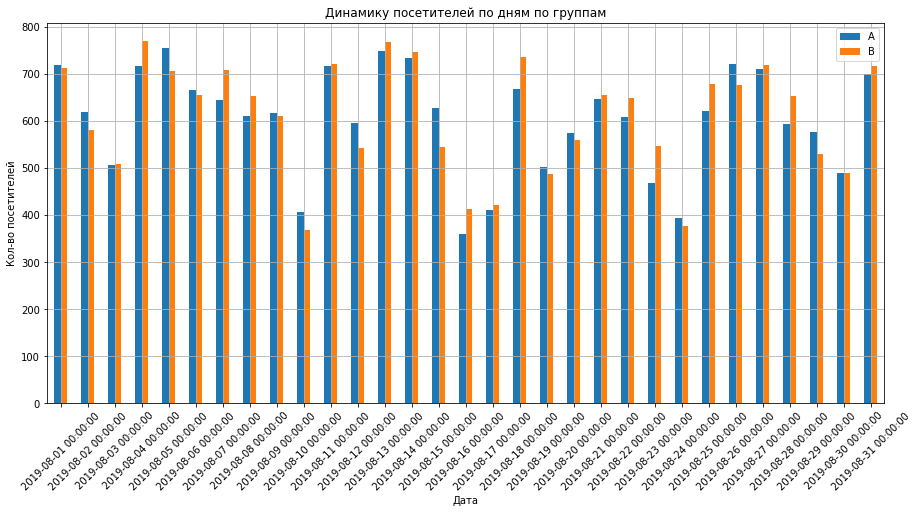

In [22]:
sales_platform = visitors.pivot_table(index='date', columns='group', values='visitors')
sales_platform.plot(kind='bar', grid=True, figsize=(15, 7))
plt.title('Динамику посетителей по дням по группам')
plt.xticks(rotation=45)
plt.legend() 
plt.ylabel('Кол-во посетителей')
plt.xlabel('Дата')
plt.show()

В основном выше 500 пользователей посещают интернет-магазин каждый день. Большее кол-во пользователей наблюдается у группы В.

***Итог:*** 
Предоставлены данные за август 2019 года. Датасет с данными о заказах не имеет пропусков и дубликатов. Исправили названия столбцов. Изменили тип данных столбца 'date'. В столбце с выручкой присутствуют аномально крупные заказы. А также на группу В приходится большее кол-во заказов и больше пользователей. Датасет с данными о пользователях не имеет пропусков и дубликатов. Изменили тип данных столбца 'date'. Наблюдается 62 пары по дате и группе - по 31 в каждой группе. 5 пользователей попали в обе группы. В основном выше 500 пользователей посещают интернет-магазин каждый день. Большее кол-во пользователей наблюдается у группы В.

### Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения

In [23]:
# удалили дубликаты по части значений
dates_groups = orders[['date','group']].drop_duplicates().sort_values(by=['date','group'])
dates_groups

,date,group
55,2019-08-01,A
66,2019-08-01,B
175,2019-08-02,A
173,2019-08-02,B
291,2019-08-03,A
...,...,...
496,2019-08-29,B
730,2019-08-30,A
690,2019-08-30,B
958,2019-08-31,A


Наблюдается 62 уникальных пар значений дат и групп теста.

In [24]:
# получаем агрегированные кумулятивные по дням данные о заказах 
orders_aggregated = dates_groups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'],\
                                                                       orders['group'] == x['group'])]. \
                                     agg({'date': 'max', 
                                          'group': 'max', 
                                          'transaction_id': pd.Series.nunique, 
                                          'visitor_id': pd.Series.nunique, 
                                          'revenue': 'sum'}), axis=1).sort_values(by=['date','group'])
# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина
visitors_aggregated = dates_groups.apply(lambda x: visitors[np.logical_and(visitors['date'] <= x['date'],\
                                                                           visitors['group'] == x['group'])]. \
                                       agg({'date': 'max', 
                                            'group': 'max', 
                                            'visitors': 'sum'}), axis=1).sort_values(by=['date','group'])
# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulative_data = orders_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

cumulative_data.head(10)

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845
5,2019-08-03,B,61,59,380996,1803
6,2019-08-04,A,84,77,425699,2562
7,2019-08-04,B,78,75,489567,2573
8,2019-08-05,A,109,100,549917,3318
9,2019-08-05,B,101,98,581995,3280


In [25]:
print(cumulative_data['date'].max())
print(orders['date'].max())
print(orders['date'].min())
print(cumulative_data['date'].min())

2019-08-31 00:00:00
2019-08-31 00:00:00
2019-08-01 00:00:00
2019-08-01 00:00:00


cumulative_data был содан корректно.

orders — кумулятивное количество заказов на указанную дату в указанной группе;\
buyers — кумулятивное количество пользователей, совершивших хотя бы один заказ, на указанную дату в указанной группе;\
revenue — кумулятивная выручка на указанную дату в указанной группе (средний чек);\
visitors — кумулятивное количество посетителей интернет-магазина на указанную дату в определённой группе.

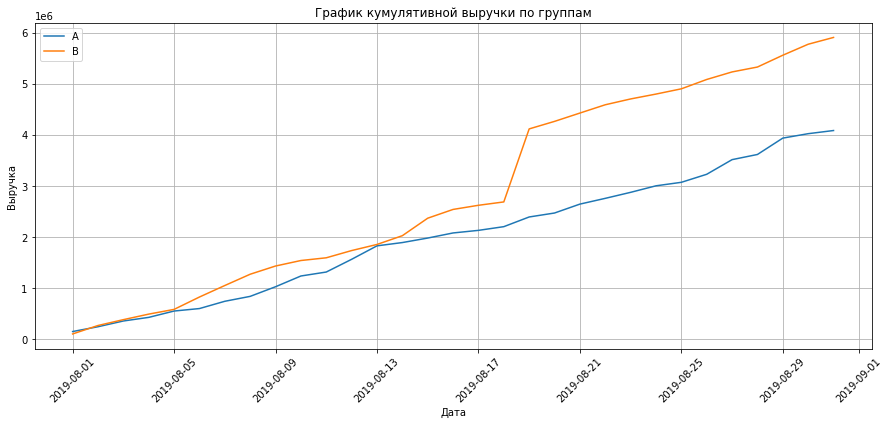

In [26]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_a = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_b = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(15,6))

# Строим график выручки группы А
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='B')

plt.xticks(rotation=45)
plt.legend() 
plt.grid()
plt.ylabel('Выручка')
plt.xlabel('Дата')
plt.title('График кумулятивной выручки по группам')
plt.show();

Выручка группы А равномерно увеличивается в течение всего теста. Выручка группы В показывает резкий скачек 18-19 числах и далее опять равномерно растет. С 1 до 13 августа выручка  обеих групп плюс минус одинакова, местами группа В с небольшим отрывом. Однако во второй половине месяца с большим отрывом по выручке уходит группа В. Возможно есть аномалии (крупные заказы).

***Итог:*** 
В целом, группа В показывает выручку больше, группы А. Если смотреть детально, в первой половине месяца кумулятивная выручка обеих групп плюс минус одинакова - равномерно росла. Во второй половине месяца с большим опережением растет выручка группы В, причем с резким скачком в 1 день. Это может сигнализировать о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке. 

### Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения

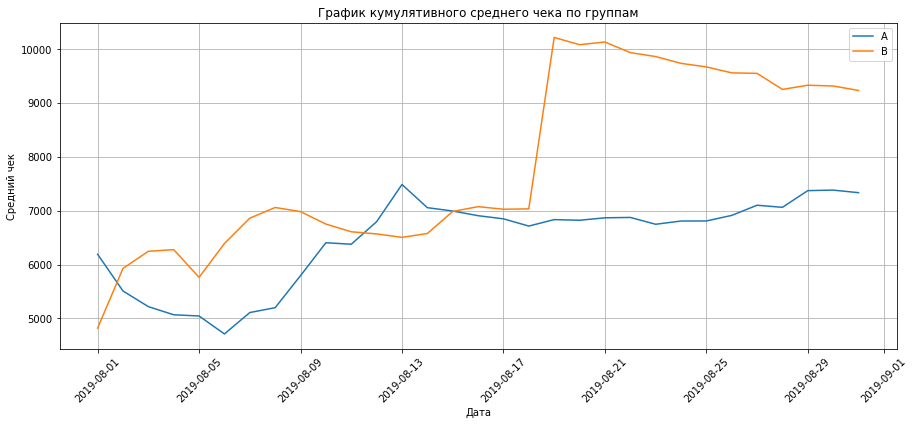

In [27]:
plt.figure(figsize=(15,6))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue']/cumulative_revenue_a['orders'], label='A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue']/cumulative_revenue_b['orders'], label='B')
plt.xticks(rotation=45)
plt.legend() 
plt.grid()
plt.ylabel('Средний чек')
plt.xlabel('Дата')
plt.title('График кумулятивного среднего чека по группам')
plt.show();

У группы В резкий всплеск 19 августа по среднему чеку, аналогично как с выручкой, а сразу после 19 числа наблюдается падение. Возможно, в группу B в этот день попали крупные заказы. Тогда ей нужно больше данных, чтобы прийти к реальному среднему чеку и установиться на его уровне.

In [28]:
#данные о заказах с 18 по 19 августа
orders.query('"2019-08-18" <= date <= "2019-08-19"').sort_values(by='revenue', ascending=False).head(10)

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,1294500,B
530,3970235543,2912540959,2019-08-19,43990,A
527,1570513684,2837914161,2019-08-19,33405,B
421,3765974140,1357170471,2019-08-19,31680,A
461,2683113224,154576532,2019-08-19,26550,B
294,3709669952,3295038680,2019-08-18,23750,A
525,3031564664,393266494,2019-08-19,21550,A
368,3268879337,2536252163,2019-08-19,20026,B
267,131747281,2579882178,2019-08-18,19538,B
366,2037051350,1957949546,2019-08-19,16770,A


Видим, что один из очень крупных заказов №425 был 19 числа.

In [29]:
orders.loc[[1196, 425]]

,transaction_id,visitor_id,date,revenue,group
1196,3936777065,2108080724,2019-08-15,202740,B
425,590470918,1920142716,2019-08-19,1294500,B


Оба крупных заказа принадлежат группе В.

In [30]:
orders_query=orders.query('"2019-08-17" <= date <= "2019-08-21"')# срез по датам 

In [31]:
orders_count=orders_query.groupby(['date','group'])['transaction_id'].count()# кол-во заказов по группам этого среза
orders_count

date        group
2019-08-17  A        10
            B        14
2019-08-18  A        17
            B         9
2019-08-19  A        22
            B        21
2019-08-20  A        12
            B        20
2019-08-21  A        23
            B        14
Name: transaction_id, dtype: int64

Количество заказов в этот день (19 августа) у группы В не сильно отличается от группы А, а также от других дней относительно самой же группы В. Следовательно, резкий скачек и по среднему чеку, и по выручке характеризуется одним очень крупным заказом - №425.

***Итог:*** 
Средний чек обеих групп скачет, что позволяет нам найти аномальные заказы. У группы А до 6 августа наблюдается падение по среднему чеку, с 6 по 13 резкое повышение, оставшаяся половина месяца плюс минус около 7000. У группы В наблюдается рост среднего чека до 19 августа, причем с резким взлетом в один день. Далее показатели среднего чека группы В падают вследствие очень крупного заказа, но все же достаточно высокие относительно группы А.  Возможно, есть всплески и по числу заказов.

### Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения

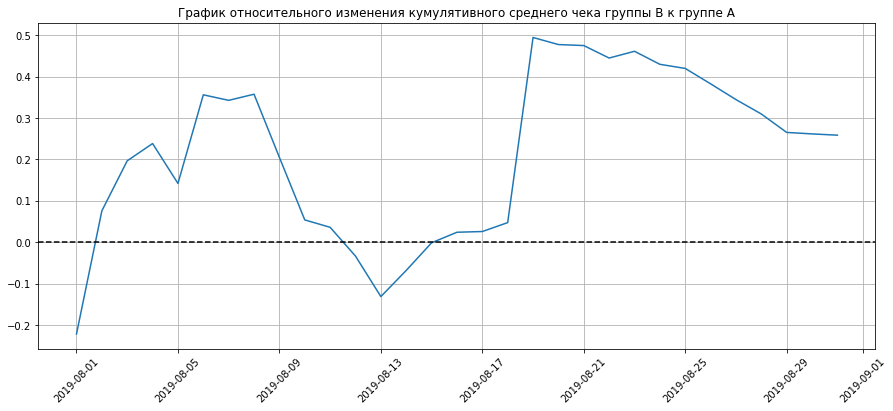

In [32]:
# собираем данные в одном датафрейме
cumulative_revenue = cumulative_revenue_a.merge(cumulative_revenue_b, left_on='date', right_on='date',\
                                                how='left', suffixes=['A', 'B'])

plt.figure(figsize=(15,6))
# cтроим отношение средних чеков
plt.plot(cumulative_revenue['date'],\
(cumulative_revenue['revenueB']/cumulative_revenue['ordersB'])/(cumulative_revenue['revenueA']/cumulative_revenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--') 
plt.xticks(rotation=45)
plt.grid()
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.show();

График разницы среднего чека группы B к группе A похож на предыдущий график - кумулятивного среднего чека группы В. Однако тут более ярко выражен еще один скачек с 1 по 8 августа. Аномальный рост среднего чека в один день 19 числа обусловлен одним очень крупным заказом, после чего естественное снижение среднего чека. 

In [33]:
orders.query('"2019-08-01" <= date <= "2019-08-09"').sort_values(by='revenue', ascending=False).head(10)

,transaction_id,visitor_id,date,revenue,group
743,3603576309,4133034833,2019-08-09,67990,A
940,2420050534,4003628586,2019-08-08,58550,B
873,2519737434,4256040402,2019-08-08,58220,B
613,4071177889,3931967268,2019-08-07,53904,B
709,514501382,950626008,2019-08-07,45880,A
173,1192036073,2953427180,2019-08-02,38160,B
420,2788225284,1606766439,2019-08-06,37550,B
654,2178722073,816783716,2019-08-07,34550,B
570,1867784682,2247666522,2019-08-04,31350,B
481,2419903539,3177790019,2019-08-06,30649,B


In [34]:
orders_query_t=orders.query('"2019-08-01" <= date <= "2019-08-09"')# срез по датам 

In [35]:
orders_count_t=orders_query_t.groupby(['date','group'])['transaction_id'].count()# кол-во заказов по группам этого среза
orders_count_t

date        group
2019-08-01  A        24
            B        21
2019-08-02  A        20
            B        24
2019-08-03  A        24
            B        16
2019-08-04  A        16
            B        17
2019-08-05  A        25
            B        23
2019-08-06  A        18
            B        28
2019-08-07  A        18
            B        24
2019-08-08  A        16
            B        27
2019-08-09  A        16
            B        25
Name: transaction_id, dtype: int64

Достаточно крупная выручка и большое кол-во заказов приходится в основном на группу В, начиная с 6 августа, у нее превосходит.

***Итог:*** 
Средний чек группы В был ниже или равен группе А только 1-2 августа и 12-15 августа, а все остальное время показывает прирост группы B. Однако этот прирост падает и не установился на определенном значении. Такие скачки в нескольких точках обусловлен всплесками числа заказов и дорогими заказами. Возможно, после очистки данных от выбросов картина изменится.

### Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения

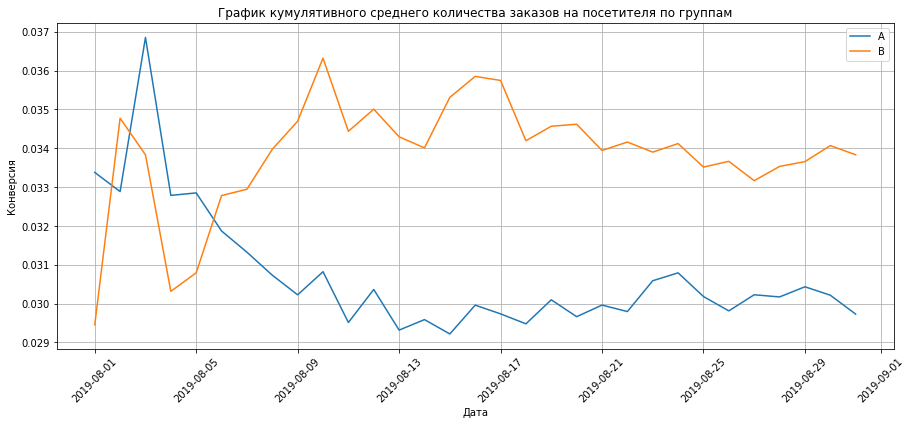

In [36]:
# считаем среднее количество заказов на посетителя
cumulative_data['conversion'] = cumulative_data['orders']/cumulative_data['visitors']

# отделяем данные по группе A
cumulative_data_a = cumulative_data[cumulative_data['group']=='A']

# отделяем данные по группе B
cumulative_data_b = cumulative_data[cumulative_data['group']=='B']

plt.figure(figsize=(15,6))
# строим графики
plt.plot(cumulative_data_a['date'], cumulative_data_a['conversion'], label='A')
plt.plot(cumulative_data_b['date'], cumulative_data_b['conversion'], label='B')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.ylabel('Конверсия')
plt.xlabel('Дата')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')
plt.show();

До 2-3 августа наблюдается рост количества заказов у обеих групп, причем группа А превосходит, а после, конверсия группы А падает и держится около 3.1%, а конверсия группы В, напротив, растет и устанавливается около 3.4%. 

***Итог:*** 
Начиная с 6 августа конверсия группы В значительно больше группы А. В целом конверсия группы В выросла относительно начала теста. А конверсия группы А, наоборот, упала и в результате ее значение меньше, чем у группы В. У группы А 3 августа аномально высокие показатели. Стоит еще проанализировать аномалии.  Возможно, после очистки данных от выбросов картина изменится.

### Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения

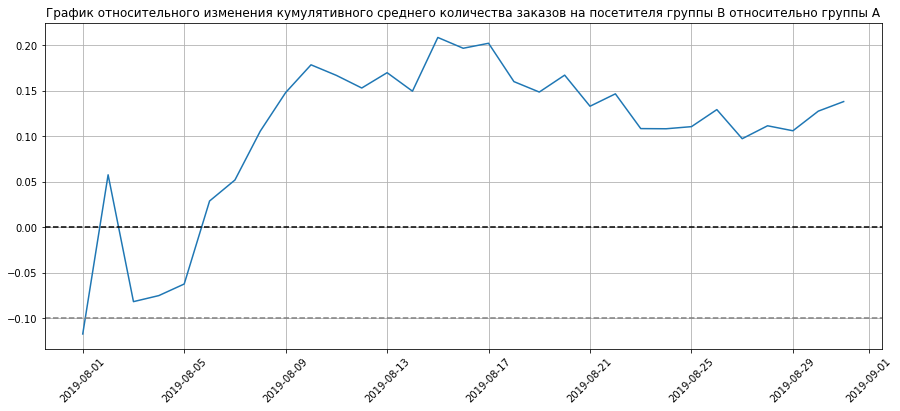

In [37]:
сumulative_сonversions = cumulative_data_a[['date','conversion']].merge(cumulative_data_b[['date','conversion']], \
    left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(15,6))
plt.plot(сumulative_сonversions['date'], сumulative_сonversions['conversionB']/сumulative_сonversions['conversionA']-1)
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B относительно группы A')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=-0.1, color='grey', linestyle='--')
plt.xticks(rotation=45)
plt.grid()
plt.show();

График разницы кумулятивного среднего количества заказов на посетителя группы B к группе A похож на предыдущий график - среднего количества заказов на посетителя группы В. 

***Итог:*** 
Начиная с 6 августа наблюдается относительный прирост конверсии группы B. Так же есть небольшой скачек 2 августа - говорит о большой активности по числу заказов в этот день. Конверсия ещё не установилась окончательно, но есть тенденции к росту. Стоит проанализировать аномалии, возможно, они изменят картину. 

### Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения

In [38]:
# таблица количества заказов по пользователям
orders_count_user = orders.groupby('visitor_id', as_index=False).agg({'transaction_id':'nunique'})\
    .rename(columns={'transaction_id':'orders'})
orders_count_user

,visitor_id,orders
0,5114589,1
1,6958315,1
2,8300375,2
3,11685486,1
4,39475350,1
...,...,...
1026,4266935830,2
1027,4278982564,1
1028,4279090005,1
1029,4281247801,1


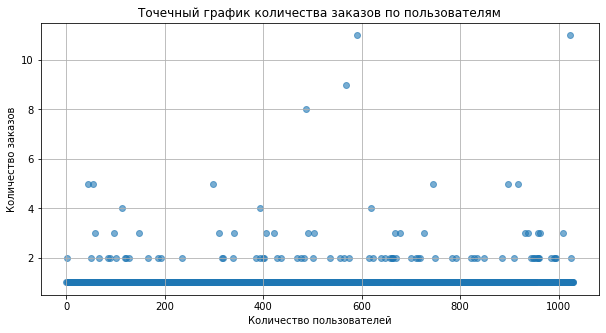

In [39]:
plt.figure(figsize=(10,5))
x_values = pd.Series(range(0,len(orders_count_user['orders'])))
plt.scatter(x_values, orders_count_user['orders'], alpha=0.6) 
plt.grid()
plt.ylabel('Количество заказов')
plt.xlabel('Количество пользователей')
plt.title('Точечный график количества заказов по пользователям')
plt.show();

 По графику можно выбрать границу в 3 заказа и выше, как аномальное число заказов, приходящихся на пользователя.

***Итог:*** 
Большинство пользователей совершает единичные заказы, чуть реже один пользователь совершает по 2 заказа. Еще реже совершают по 3 заказа. Возможно, это уже выбросы. Однако принято отсеивать от 1% до 5% наблюдений с крайними значениями. Чтобы точно определить границу аномальных пользователей, необходимо посчитать процентили (95 и 99).

### Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей

In [40]:
print('95 и 99 перцентили количества заказов на пользователя:', np.percentile(orders_count_user['orders'], [95, 99])) 

95 и 99 перцентили количества заказов на пользователя: [2. 4.]


***Итог:*** 
Не более 5% пользователей совершают более 2 заказов и не более 1% совершают более 4 заказов. Все, что за 95 перцентилем будем считать аномалиями. То есть более 2-ух заказа на одного пользователя будем считать за верхнюю границу числа заказов, и отсеивать аномальных пользователей по ней.

#### Постройте точечный график стоимостей заказов. Сделайте выводы и предположения

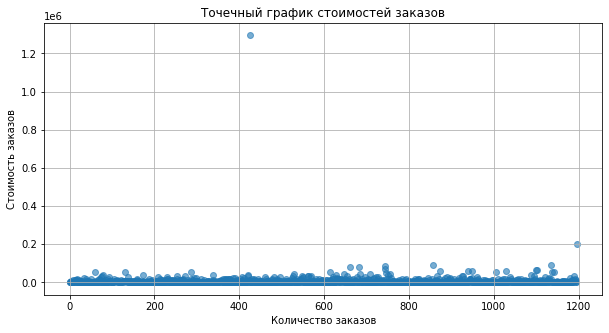

In [41]:
plt.figure(figsize=(10,5))
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'], alpha=0.6)
plt.grid()
plt.ylabel('Стоимость заказов')
plt.xlabel('Количество заказов')
plt.title('Точечный график стоимостей заказов')
plt.show()

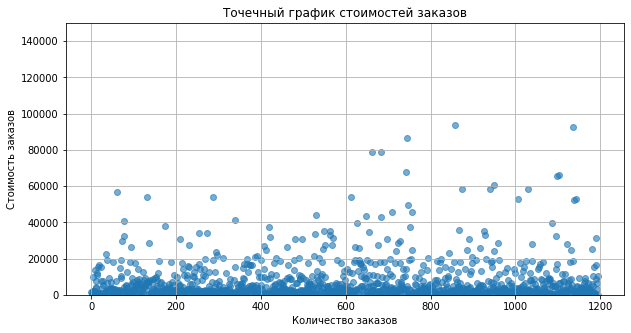

In [42]:
# точечный график стоимостей заказов в пределах нормальных значений
plt.figure(figsize=(10,5))
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'], alpha=0.6)
plt.grid()
plt.ylim (0, 150000)
plt.ylabel('Стоимость заказов')
plt.xlabel('Количество заказов')
plt.title('Точечный график стоимостей заказов')
plt.show()

***Итог:*** 
Наблюдается пару аномальных заказов: один свыше 1.2 млн. и другой за 200 тыс.руб. В основном все заказы до 100 тыс.руб. Возможно это и есть граница, выше которой находятся выбросы. Но чтобы точно определить границу аномальных заказов, необходимо посчитать процентили (95 и 99). 

### Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов

In [43]:
print('95 и 99 перцентили стоимости заказов:', np.percentile(orders['revenue'], [95, 99])) 

95 и 99 перцентили стоимости заказов: [28000.  58233.2]


***Итог:*** 
Не более 5% заказов стоимостью дороже 28000 рублей и не более 1% заказов дороже 58233.2 рублей. Все, что за 99 перцентилем будем считать аномалиями. 

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения

Сформулируем гипотезы.\
Нулевая: различий в среднем количестве заказов между группами по «сырым» данным нет.\
Альтернативная: различия в среднем количестве заказов между группами по «сырым» данным есть.

In [44]:
# создали ДФ с количеством пользователей в выбранную дату в группе A
visitors_a_daily = visitors[visitors['group']=='A'][['date', 'visitors']].rename(columns={'visitors':'visitors_perdate_a'})

# создали ДФ с количеством пользователей до выбранной даты включительно в группе A
visitors_a_cummulative = visitors_a_daily.apply(lambda x: visitors_a_daily[visitors_a_daily['date'] <= x['date']]\
                                                .agg({'date': 'max', 'visitors_perdate_a': 'sum'}), axis=1)\
                                                .rename(columns={'visitors_perdate_a':'visitors_cummulative_a'})

# создали ДФ с количеством пользователей в выбранную дату в группе B
visitors_b_daily = visitors[visitors['group']=='B'][['date', 'visitors']].rename(columns={'visitors':'visitors_perdate_b'})

# создали ДФ с количеством пользователей до выбранной даты включительно в группе B
visitors_b_cummulative = visitors_b_daily.apply(lambda x: visitors_b_daily[visitors_b_daily['date'] <= x['date']]\
                                                .agg({'date' : 'max', 'visitors_perdate_b' : 'sum'}), axis=1)\
                                                .rename(columns={'visitors_perdate_b':'visitors_cummulative_b'})

# создали ДФ с количеством заказов и суммарной выручкой в выбранную дату в группе A
orders_a_daily = orders[orders['group']=='A'][['date', 'transaction_id', 'visitor_id', 'revenue']]\
    .groupby('date', as_index=False)\
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
orders_a_daily.columns = ['date', 'orders_perdate_a', 'revenue_perdate_a']

# создали ДФ с суммарным числом заказов и суммарной выручкой до выбранной даты включительно в группе A
orders_a_cummulative = orders_a_daily.apply(
    lambda x: \
        orders_a_daily[orders_a_daily['date'] <= x['date']]\
            .agg({
                'date': 'max',
                'orders_perdate_a': 'sum',
                'revenue_perdate_a': 'sum'}), axis=1).sort_values(by=['date'])
orders_a_cummulative.columns = ['date', 'orders_cummulative_a', 'revenue_cummulative_a']

# создали ДФ с количеством заказов и суммарной выручкой в выбранную дату в группе B
orders_b_daily = orders[orders['group']=='B'][['date', 'transaction_id', 'visitor_id', 'revenue']]\
    .groupby('date', as_index=False)\
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
orders_b_daily.columns = ['date', 'orders_perdate_b', 'revenue_perdate_b']

# создали ДФ с суммарным числом заказов и суммарной выручкой до выбранной даты включительно в группе B
orders_b_cummulative = orders_b_daily.apply(
    lambda x: \
        orders_b_daily[orders_b_daily['date'] <= x['date']]\
            .agg({
                'date': 'max',
                'orders_perdate_b': 'sum',
                'revenue_perdate_b': 'sum'}), axis=1).sort_values(by=['date'])
orders_b_cummulative.columns = ['date', 'orders_cummulative_b', 'revenue_cummulative_b']

In [45]:
# единная таблица 
dt = orders_a_daily.merge(orders_b_daily, left_on='date', right_on='date', how='left')\
    .merge(orders_a_cummulative, left_on='date', right_on='date', how='left')\
    .merge(orders_b_cummulative, left_on='date', right_on='date', how='left')\
    .merge(visitors_a_daily, left_on='date', right_on='date', how='left')\
    .merge(visitors_b_daily, left_on='date', right_on='date', how='left')\
    .merge(visitors_a_cummulative, left_on='date', right_on='date', how='left')\
    .merge(visitors_b_cummulative, left_on='date', right_on='date', how='left')

display(dt.head(5)) 

,date,orders_perdate_a,revenue_perdate_a,orders_perdate_b,revenue_perdate_b,orders_cummulative_a,revenue_cummulative_a,orders_cummulative_b,revenue_cummulative_b,visitors_perdate_a,visitors_perdate_b,visitors_cummulative_a,visitors_cummulative_b
0,2019-08-01,24,148579,21,101217,24,148579,21,101217,719,713,719,713
1,2019-08-02,20,93822,24,165531,44,242401,45,266748,619,581,1338,1294
2,2019-08-03,24,112473,16,114248,68,354874,61,380996,507,509,1845,1803
3,2019-08-04,16,70825,17,108571,84,425699,78,489567,717,770,2562,2573
4,2019-08-05,25,124218,23,92428,109,549917,101,581995,756,707,3318,3280


In [46]:
# создали ДФ по пользователям с числом совершённых заказов в группе A
orders_users_a = orders[orders['group']=='A'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_users_a.columns = ['user_id', 'orders']

# создали ДФ по пользователям с числом совершённых заказов в группе B
orders_users_b = orders[orders['group']=='B'].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_users_b.columns = ['user_id', 'orders']

display(orders_users_a.head(5), orders_users_b.head(5)) 

,user_id,orders
0,8300375,1
1,11685486,1
2,54447517,1
3,66685450,1
4,78758296,1


,user_id,orders
0,5114589,1
1,6958315,1
2,8300375,1
3,39475350,1
4,47206413,1


Переменные sample_a и sample_b содержат количество заказов посетителей из разных групп соответственно. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни.
Число элементов в переменных - это количество посетителей группы, а сумма всех элементов — количество заказов. 

In [47]:
sample_a = pd.concat([orders_users_a['orders'],pd.Series(0, index=np.arange(dt['visitors_perdate_a'].sum()\
    - len(orders_users_a['orders'])), name='orders')],axis=0)

sample_b = pd.concat([orders_users_b['orders'],pd.Series(0, index=np.arange(dt['visitors_perdate_b'].sum()\
    - len(orders_users_b['orders'])), name='orders')],axis=0)

# кол-во заказов и кол-во посетителей по группам А и В соответственно
sample_a.value_counts(), sample_b.value_counts()

(0    18233
 1      473
 2       17
 3        7
 4        3
 5        2
 7        1
 Name: orders, dtype: int64,
 0    18330
 1      552
 2       23
 3        5
 4        4
 5        1
 6        1
 Name: orders, dtype: int64)

Чтобы получить среднее кол-во заказов на посетителя, поделим сумму заказов на число посетителей — найдём среднее в выборке sample_a методом mean(). Аналогично найдём среднее группы B: sample_a.mean().\
Относительный прирост среднего числа заказов группы B: среднее число заказов группы B / среднее число заказов группы A - 1

In [48]:
# применим критерий Манна-Уитни и отформатируем p-value, округлив его до трёх знаков после запятой
alpha=0.05
print('p-value = {0:.3f}'.format(stats.mannwhitneyu(sample_a, sample_b)[1]))
print('Относительное различие среднего числа заказов группы B к группе А по сырым данным = {0:.3f}'\
      .format(sample_b.mean()/sample_a.mean()-1)) 

p-value = 0.017
Относительное различие среднего числа заказов группы B к группе А по сырым данным = 0.138


p-value меньше 0.05, следовательно, нулевую гипотезу о том, что статистически значимых различий в среднем количестве заказов между группами нет, отвергаем в пользу альтернативной гипотезы. И относительный прирост среднего числа заказов группы B над группой А составляет 13.8%.

***Итог:*** 
Анализ сырых данных показал статистически значимые различия в среднем количестве заказов на посетителя между группами. Причем относительный прирост среднего числа заказов группы B к группе А составляет 13.8%.

### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения

Сформулируем гипотезы.\
Нулевая: различий в среднем чеке заказа между группами по «сырым» данным нет.\
Альтернативная: различия в среднем чеке между группами по «сырым» данным есть.

In [49]:
print('p-value = {0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], \
                                                    orders[orders['group']=='B']['revenue'])[1]))
print('Относительное различие среднего чека группы B к группе А по сырым данным = {0:.3f}'\
      .format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1)) 

p-value = 0.729
Относительное различие среднего чека группы B к группе А по сырым данным = 0.259


***Итог:*** 
p-value больше 0.05, следовательно, нулевую гипотезу о том, что статистически значимых различий в среднем чеке заказа между группами по «сырым» данным нет, не отвергаем. Однако относительный прирост группы B равен 25.9%. \
Несмотря на такое различие между сегментами, наблюдаемые различия не являются значимыми при таком уровне значимости, а следовательно были получены случайно. Стоит присмотреться к выбросам.

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения

Сформулируем гипотезы.\
Нулевая: различий в среднем количестве заказов между группами по «очищенным» данным нет.\
Альтернативная: различия в среднем количестве заказов между группами по «очищенным» данным есть.

In [50]:
# сделаем срезы пользователей с числом заказов больше 2
users_with_many_orders = pd.concat([orders_users_a[orders_users_a['orders'] > np.percentile(orders_users_a['orders'], 95)]['user_id'],\
                                    orders_users_b[orders_users_b['orders'] > np.percentile(orders_users_b['orders'], 95)]['user_id'],], axis=0)
# сделаем срезы пользователей, совершивших заказы дороже 58233.2
users_with_expensive_orders = orders[orders['revenue'] > np.percentile(orders['revenue'], 99)]['visitor_id']

# объединенная таблица 
abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates().sort_values()

print(abnormal_users.head(5))
print("Количество аномальных посетителей = " ,len(abnormal_users)) 

1099    148427295
18      199603092
23      237748145
37      249864742
68      457167155
dtype: int64
Количество аномальных посетителей =  31


Необходимо понять, как эти посетители повлияли на результаты теста. Аналогично посчитаем статистическую значимость различий в среднем количестве заказов между группами теста, но уже по очищенным данным. Для этого подготовим выборки количества заказов по пользователям по группам теста:

In [51]:
sample_a_filtered = pd.concat([orders_users_a[np.logical_not(orders_users_a['user_id'].isin(abnormal_users))]['orders'], \
                             pd.Series(0, index=np.arange(dt['visitors_perdate_a'].sum() - len(orders_users_a['orders'])), \
                                       name='orders')],axis=0)

sample_b_filtered = pd.concat([orders_users_b[np.logical_not(orders_users_b['user_id'].isin(abnormal_users))]['orders'], \
                             pd.Series(0, index=np.arange(dt['visitors_perdate_b'].sum() - len(orders_users_b['orders'])), \
                                       name='orders')],axis=0) 

# кол-во заказов и кол-во посетителей по группам А и В соответственно
sample_a_filtered.value_counts() , sample_b_filtered.value_counts()

(0    18233
 1      461
 2       17
 Name: orders, dtype: int64,
 0    18330
 1      543
 2       22
 Name: orders, dtype: int64)

In [52]:
alpha=0.05
print('p-value = {0:.3f}'.format(stats.mannwhitneyu(sample_a_filtered, sample_b_filtered)[1]))
print('Относительное различие среднего числа заказов группы B к группе А по очищенным данным = {0:.3f}'\
      .format(sample_b_filtered.mean()/sample_a_filtered.mean()-1)) 

p-value = 0.010
Относительное различие среднего числа заказов группы B к группе А по очищенным данным = 0.174


Результаты по среднему количеству заказов практически не изменились. 

***Итог:*** 
p-value по очищенным данным стал еще меньше, но так же меньше 0.05, следовательно, нулевую гипотезу о том, что статистически значимых различий в среднем количестве заказов между группами нет, отвергаем в пользу альтернативной гипотезы. А относительный прирост среднего числа заказов по очищенным данным группы B над группой А стал больше - 17.4%.

### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения

Сформулируем гипотезы.\
Нулевая: различий в среднем чеке заказа между группами по «очищенным» данным нет.\
Альтернативная: различия в среднем чеке между группами по «очищенным» данным есть.

In [53]:
print('p-value = {0:.3f}'.format(stats.mannwhitneyu(orders[np.logical_and(orders['group'] == 'A',\
    np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'],
                                          orders[np.logical_and(orders['group'] == 'B',\
    np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'],)[1]))

print('Относительное различие среднего чека группы B к группе А по очищенным данным = {0:.3f}'\
      .format(orders[np.logical_and(orders['group'] == 'B',\
    np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'].mean()/orders[np.logical_and(orders['group']=='A',\
    np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'].mean() - 1)) 

p-value = 0.798
Относительное различие среднего чека группы B к группе А по очищенным данным = -0.020


***Итог:*** 
p-value по очищенным данным стал чуть больше и так же больше 0.05, следовательно, нулевую гипотезу о том, что статистически значимых различий в среднем чеке заказа между группами по «сырым» данным нет, опять же не отвергаем. Однако относительный прирост группы B стал проигрышем 2%. Это обусловлено воздействием аномально крупными заказами. 

### Примите решение по результатам теста и объясните его. Варианты решений:
1. Остановить тест, зафиксировать победу одной из групп.
2. Остановить тест, зафиксировать отсутствие различий между группами.
3. Продолжить тест.

На основании результатов статистического теста принимается решение остановить тест, зафиксировать победу за группой В.

***Итог:*** 
- Есть статистически значимое различие по конверсии между группами как по сырым данным, так и после фильтрации аномалий.
- Нет статистически значимого различия по среднему чеку между группами по сырым данным, так и после фильтрации аномалий. Однако после удаления аномалий относительный прирост среднего чека группы B в 25.9% превратился в проигрыш в 2%. Другими словами, среднии чеки примерно равны.
- График различия конверсии между группами сообщает, что результаты группы B лучше группы A - есть тенденция к росту.
- График различия среднего чека колеблется, что позволяет выявить аномальные заказы.

Гипотезы были направлены на увеличение клиентской базы и повышение конверсии. Группа В показала хороший результат - прирост конверсии группы В(17.4%). Результат статистического теста по среднему чеку оказался не значимый в различии.

По данным результатам принимается решение остановить тест, зафиксировать победу за группой В. 

***Вывод:*** 

Анализ А/В-теста показал следующие результаты:
- кумулятивная выручка в первой половине месяца обеих групп плюс минус одинакова - равномерно росла, а во второй половине месяца с большим опережением растет выручка группы В, причем с резких скачком в один день. Сигнал о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке;
- кумулятивный средний чек обеих групп скачет - сигнал об аномальных заказах. К концу месяца показатели группы А стабилизировались около 7000 руб., а вот у группы В после резкого всплеск 19 августа наблюдается падение, вследствие очень крупного заказа, но все же достаточно высокие относительно группы А;
- график относительного изменения кумулятивного среднего чека группы B к группе A скачет и показал, что есть всплески числа заказов. В целом, наблюдается прирост кумулятивного среднего чека группы B. Однако этот прирост падает и не установился на определенном значении, но выше группы А;
- график кумулятивной конверсии выявил всплеск числа заказов в начале месяца у группы А, а так же установил, что конверсия группы В значительно больше группы А;
- график относительного изменения кумулятивной конверсии группы B к группе A показал прирост группы B начиная уже с 6 августа;
- не более 5% пользователей совершают более 2 заказов и не более 1% совершают более 4 заказов. Более 2-ух заказов на одного пользователя - верхняя граница числа заказов аномальных пользователей;
- не более 5% заказов стоимостью дороже 28000 рублей и не более 1% заказов дороже 58233.2 рублей. Заказ на сумму более 58233.2 рублей - аномальные заказы;
- конверсия у групп имеет значимое различие и по сырым данным, и по очищенным, но по очищенным данным результат в различии стал более значимый и пророст группы В стал на 3.6% выше;
- средний чек не показал значимых различий ни по сырым, ни по очищенным данным. Результат по очищенным данным показал еще более ясно, что различия не значимы. А вот относительный прирост группы В в 25.9% по сырым данным стал относительным проигрышем в 2% по очищенным данным. Такая перемена обусловлена действием аномальных заказов. Как только удалили выбросы, средние чеки практически сравнялись.

Обнаружено 2 аномальных заказа №425 и 1196 с крупной выручкой, принадлежащие группе В. А также большое кол-во заказов приходится в основном на группу В.

Наиболее перспективные гипотезы направлены на увеличение клиентской базы и повышение конверсии. По результатам статистического теста группа В показала хороший результат по конверсии - прирост конверсии группы В в 17.4%. При одинаковом среднем чеке, конверсия группы В выше - однозначно позитивный результат.

По данным результатам принимается решение остановить тест, зафиксировать победу за группой В. Гипотезы подтвердились.

***Общий вывод:*** 

В целях увеличения выручки крупного интернет-магазина была проведена приоритизация гипотезы и анализ результатов А/В-теста.
Точная оценка гипотез зависит от метода, поэтому смотрим на место гипотез относительно друг другу, а не на абсолютную оценку. Применение метода RICE для приоритизации гипотез, в отличии от ICE, учитывает число пользователей, которых затронет изменение. Наиболее перспективные гипотезы по фреймворку RICE направлены на увеличение клиентской базы и повышению конверсии.

На этапе предобработки данных датафреймов с результатами А/В-теста никаких пропусков и дубликатов обнаружено не было. Названия столбцов привели к нормам стиля и изменили тип данных столбцов 'date'. Данные предоставлены за август 2019 года. Были обнаружены выбросы в столбце с выручкой. А также на группу В приходится большее кол-во заказов и больше пользователей. Слияние двух датафреймов в один предоставило 62 уникальные пары значений дат и групп теста. В основном выше 500 пользователей посещают интернет-магазин каждый день.

А/В-тест показал:
- Есть статистически значимое различие по конверсии между группами как по сырым данным, так и после фильтрации аномалий.
- Нет статистически значимого различия по среднему чеку между группами по сырым данным, так и после фильтрации аномалий.
- График различия конверсии между группами сообщает, что результаты группы B лучше группы A - есть тенденция к росту.
- График различия среднего чека колеблется, что позволяет выявить аномальные заказы.

Достаточно крупная выручка и большое кол-во заказов приходится в основном на группу В, начиная с 6 августа. После удаления аномальных заказов относительный прирост среднего чека группы B в 25.9% превратился в проигрыш в 2%. Другими словами, средние чеки сравнялись. А так как при одинаковом среднем чеке, конверсия группы В оказалась выше группы А на 17.4% и наиболее перспективные гипотезы направлены на увеличение клиентской базы и повышение конверсии, то тест признан успешным - победа за группой В.